REad in a WISP-compatible InSAR file and plot in PyGMT

In [ ]:

# file='/Users/hyin/usgs_mendenhall/events/2026_venezuela/ffm/resampled_interferograms/nisar_t61_20260618_20260630.txt'
# file='/Users/hyin/usgs_mendenhall/events/2026_venezuela/ffm/resampled_interferograms/nisar_t162_20260613_20260625.txt'
# file='/Users/hyin/usgs_mendenhall/events/2026_venezuela/ffm/resampled_interferograms/nisar_t162_20260613_20260625_mask.txt'
dir ='/Users/hyin/usgs_mendenhall/events/2026-07-28_kumamoto/nisar/'
# filestem='nisar_t61_20260618_20260630'
filestem='nisar-p024-20260721-20260814_resampled'
file=f'{dir}{filestem}.txt'


In [5]:
import pandas as pd

df = pd.read_csv(
    file,
    delim_whitespace=True,
    comment="#",
    names=["lon", "lat", "los", "look_n", "look_e","look_u"],   # adjust if you have more columns
)

print(df.head())

          lon        lat       los    look_n    look_e    look_u
0  130.362794  32.783357 -0.087591 -0.656453  0.115375 -0.745491
1  130.558185  33.491493 -0.044858 -0.653198  0.114735 -0.748435
2  130.576292  32.053948 -0.076700 -0.631270  0.113438 -0.767197
3  130.351632  32.433662 -0.134662 -0.652458  0.115210 -0.749013
4  130.847014  32.048240 -0.082456 -0.610546  0.111321 -0.784107


/var/folders/x7/q8y3dbkj0gv831q8bnwtym_c0000gp/T/ipykernel_51671/4064024503.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


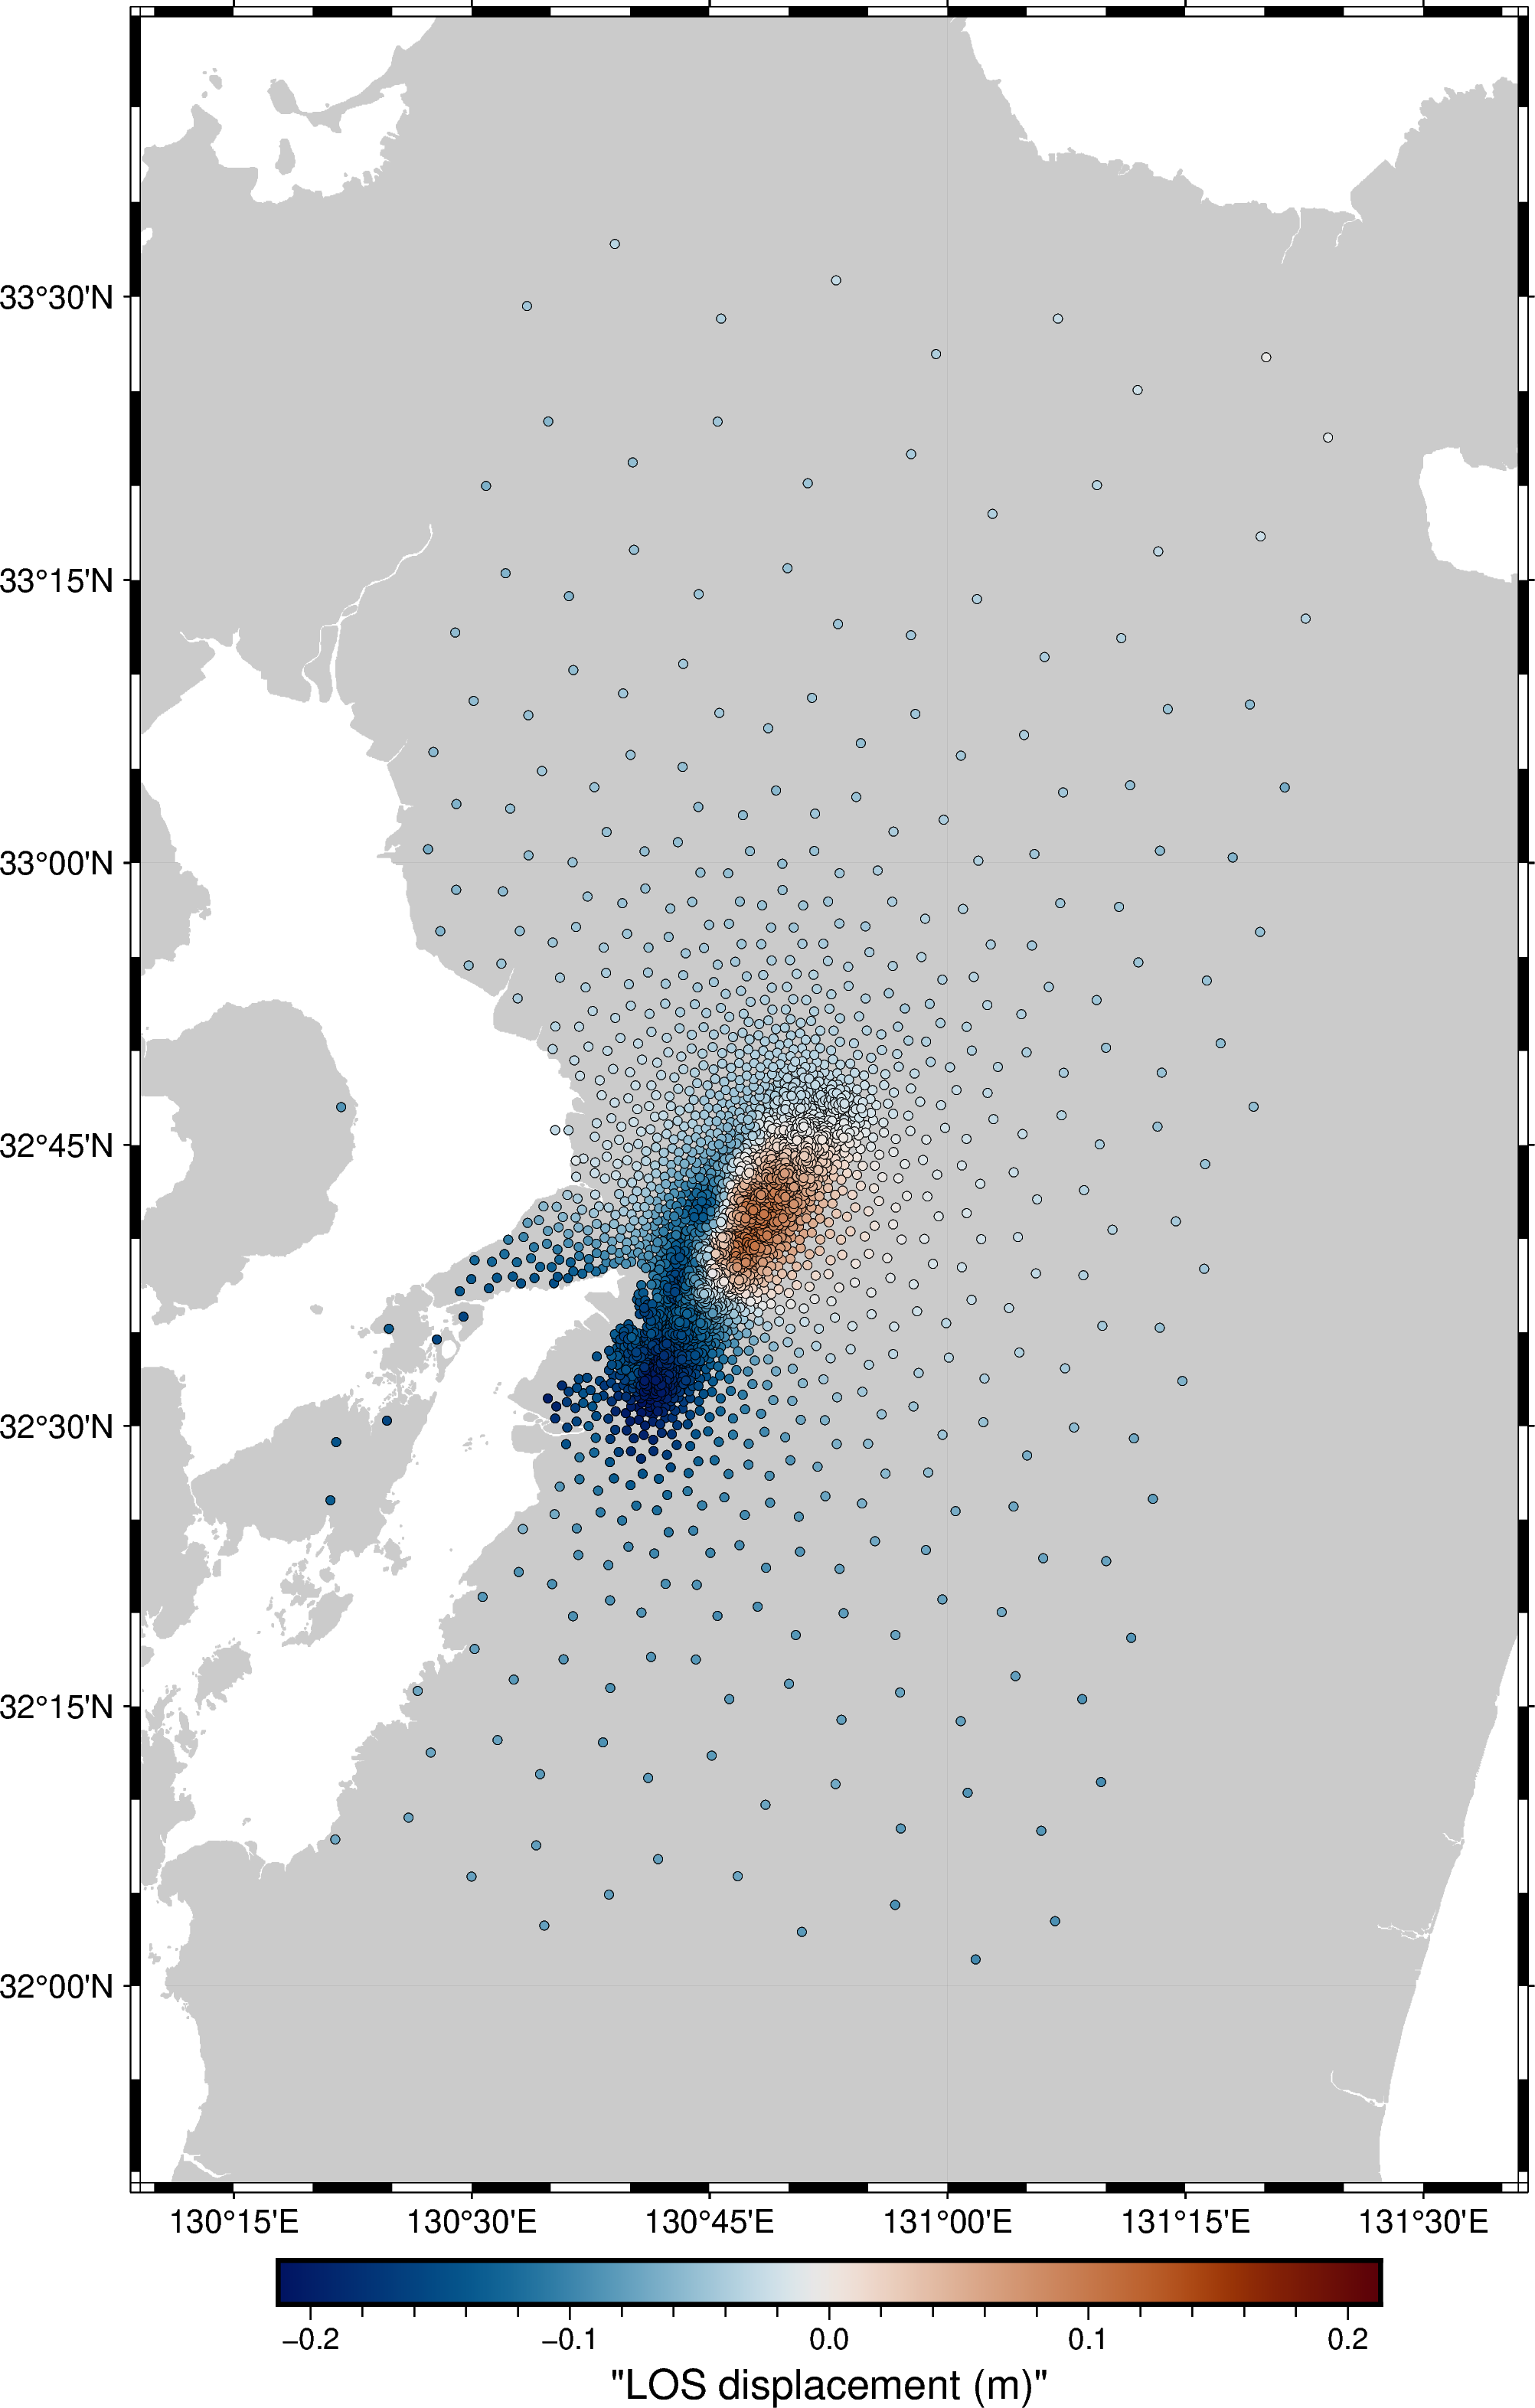

In [6]:
import pygmt

fig = pygmt.Figure()

region = [
    df.lon.min() - 0.2,
    df.lon.max() + 0.2,
    df.lat.min() - 0.2,
    df.lat.max() + 0.2,
]
projection="M6i"  # 6-inch map width


vmax = max(abs(df.los.min()), abs(df.los.max()))

pygmt.makecpt(
    cmap="vik",
    series=[-vmax, vmax],
)
fig.coast(land="darkgray", transparency=40,region=region,projection=projection,)
fig.basemap(
    region=region,
    projection=projection,
    frame=True,
)

fig.plot(
    x=df["lon"],
    y=df["lat"],
    style="c0.1c",      # circles 0.08 cm diameter
    fill=df["los"],      # color by LOS value
    cmap=True,
    pen="0.05p,black",
)

fig.colorbar(frame='af+l"LOS displacement (m)"')

fig.show()
fig.savefig(f'{dir}{filestem}.png')